# **1. Perkenalan Dataset**


**Sumber Dataset**:  
   Dataset yang dipakai adalah fetch_california_housing yang diambil dari scikit-learn dataset


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Dataset California Housing
from sklearn.datasets import fetch_california_housing

# Untuk preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Library berhasil diimport")

Library berhasil diimport


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load dataset
california = fetch_california_housing(as_frame=True)

df = california.frame
df['MedHouseVal'] = california.target

# Simpan dataset ke format .csv
df.to_csv('california_housing.csv', index=False)

# Lihat isi data
print(f"\nJumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

print(df.head())


Jumlah baris: 20640
Jumlah kolom: 9
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Statistik deskriptif
print("STATISTIK DESKRIPTIF")
print("="*20)
print(df.describe())



STATISTIK DESKRIPTIF
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        

In [5]:
# Cek missing values
print("MISSING VALUES")
print("="*15)
print(df.isnull().sum())

MISSING VALUES
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


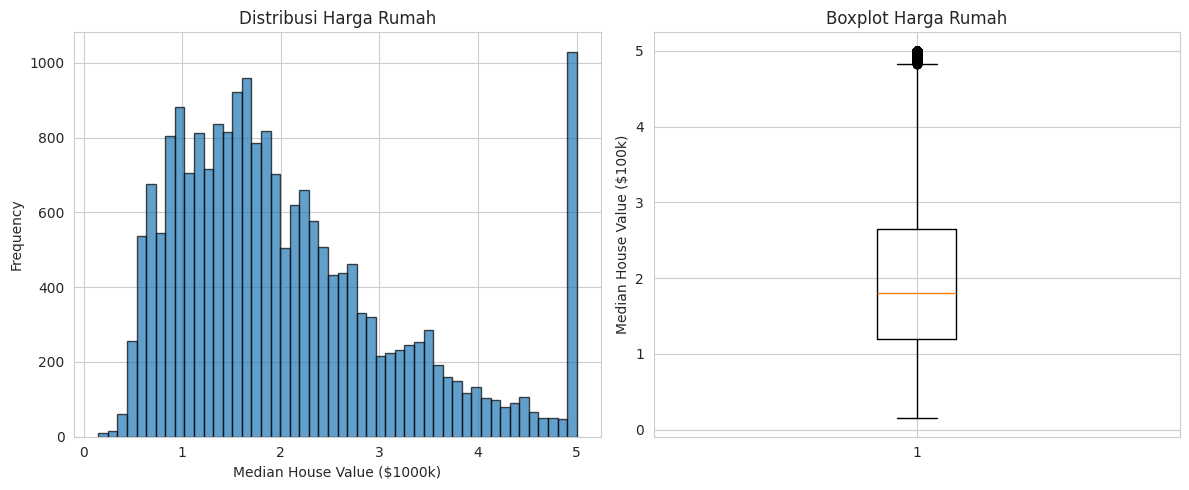

In [6]:
# Distribusi target variable
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Median House Value ($1000k)')
plt.ylabel('Frequency')
plt.title('Distribusi Harga Rumah')

plt.subplot(1, 2, 2)
plt.boxplot(df['MedHouseVal'])
plt.ylabel('Median House Value ($100k)')
plt.title('Boxplot Harga Rumah')

plt.tight_layout()
plt.show()

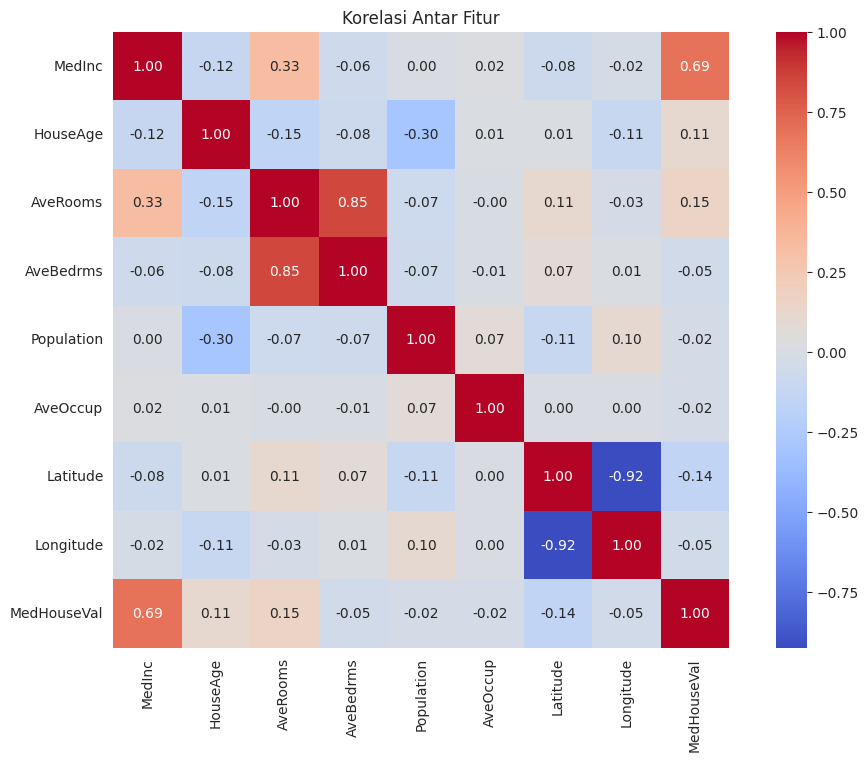

In [7]:
# Korelasi antar fitur
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Korelasi Antar Fitur')
plt.show()

Dalam korelasi tersebut dapat dilihat bahwa fitur dengan jumlah kamar sangat berpengaruh dengan jumlah kamar tidur.

In [8]:
# Melihat fitur yang paling berkorelasi dengan target
corr_with_target = correlation_matrix['MedHouseVal'].sort_values(ascending=False)
print("KORELASI DENGAN TARGET (MedHouseVal)")
print("="*36)
print(corr_with_target)

KORELASI DENGAN TARGET (MedHouseVal)
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


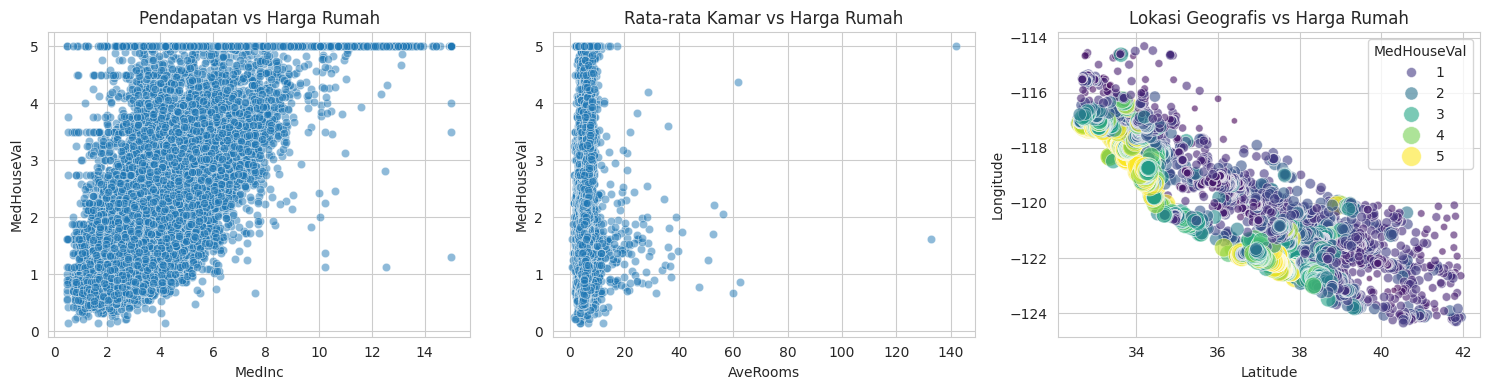

In [9]:
# Membaca fitur penting lainnya dengan scatter plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x='MedInc', y='MedHouseVal', alpha=0.5, ax=axes[0])
axes[0].set_title('Pendapatan vs Harga Rumah')

sns.scatterplot(data=df, x='AveRooms', y='MedHouseVal', alpha=0.5, ax=axes[1])
axes[1].set_title('Rata-rata Kamar vs Harga Rumah')

sns.scatterplot(data=df, x='Latitude', y='Longitude', hue='MedHouseVal',
                palette='viridis', size='MedHouseVal', sizes=(20, 200), alpha=0.6, ax=axes[2])
axes[2].set_title('Lokasi Geografis vs Harga Rumah')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# Buat copy dataset untuk preprocessing
df_processed = df.copy()

print(f"Missing values: {df_processed.isnull().sum().sum()}")
print(f"Jumlah data: {len(df_processed)}")

Missing values: 0
Jumlah data: 20640


In [11]:
# Handle missing values
if df_processed.isnull().sum().sum() > 0:

    # Impute dengan median untuk numerical features
    imputer = SimpleImputer(strategy='median')
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    df_processed[numeric_cols] = imputer.fit_transform(df_processed[numeric_cols])
    print("Missing values telah diisi dengan median")
else:
    print("Tidak ada missing values")

Tidak ada missing values


In [12]:
# Cek dan hapus duplikat
duplicates = df_processed.duplicated().sum()
print(f"   Jumlah data duplikat: {duplicates}")
if duplicates > 0:
    df_processed = df_processed.drop_duplicates()
    print(f"{duplicates} data duplikat dihapus")

   Jumlah data duplikat: 0


In [ ]:
# Pisahkan fitur dan target
X = df_processed.drop('MedHouseVal', axis=1)
y = df_processed['MedHouseVal']

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Fitur interaksi: Rooms per household
df_processed['RoomsPerHousehold'] = df_processed['AveRooms'] / df_processed['AveOccup']

# Fitur interaksi: Bedrooms per room
df_processed['BedroomsPerRoom'] = df_processed['AveBedrms'] / df_processed['AveRooms']

# Fitur populasi per household
df_processed['PopulationPerHousehold'] = df_processed['Population'] / df_processed['AveOccup']

print(f"   ✅ Fitur baru ditambahkan: RoomsPerHousehold, BedroomsPerRoom, PopulationPerHousehold")

   ✅ Fitur baru ditambahkan: RoomsPerHousehold, BedroomsPerRoom, PopulationPerHousehold


In [23]:
# Deteksi dan handle outliers
outlier_count = 0
for col in df_processed.select_dtypes(include=[np.number]).columns:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_processed[col] < (Q1 - 1.5 * IQR)) | (df_processed[col] > (Q3 + 1.5 * IQR))).sum()

    if outliers > 0:
        outlier_count += outliers
        print(f"   - {col}: {outliers} outliers")

print(f"   - {col}: {outliers} outliers")

   - MedInc: 681 outliers
   - AveRooms: 511 outliers
   - AveBedrms: 1424 outliers
   - Population: 1196 outliers
   - AveOccup: 711 outliers
   - MedHouseVal: 1071 outliers
   - RoomsPerHousehold: 402 outliers
   - BedroomsPerRoom: 591 outliers
   - PopulationPerHousehold: 1220 outliers
   - PopulationPerHousehold: 1220 outliers


In [24]:
bounds_dict = {}

for col in df_processed.select_dtypes(include=[np.number]).columns:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    bounds_dict[col] = (lower_bound, upper_bound)

# Menangani outlier dengan clipping
df_processed[col] = df_processed[col].clip(lower_bound, upper_bound)

if outliers > 0:
  print(f"   - {col}: {outliers} outliers telah ditangani")

   - PopulationPerHousehold: 1220 outliers telah ditangani


In [27]:
# Binning untuk target variable
bins = [0, 1, 2, 3, 4, 5, 5.1]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High', 'Extreme']
df_processed['PriceCategory'] = pd.cut(df_processed['MedHouseVal'], bins=bins, labels=labels)

# Binning untuk pendapatan
income_bins = [0, 2, 4, 6, 8, 10, 15]
income_labels = ['Very Low', 'Low', 'Medium-Low', 'Medium', 'Medium-High', 'High']
df_processed['IncomeCategory'] = pd.cut(df_processed['MedInc'], bins=income_bins, labels=income_labels)

print("✅ Binning telah ditambahkan")
print(df_processed[['PriceCategory', 'IncomeCategory']].head())

✅ Binning telah ditambahkan
  PriceCategory IncomeCategory
0     Very High    Medium-High
1          High    Medium-High
2          High         Medium
3          High     Medium-Low
4          High            Low


In [28]:
print("SETELAH PREPROCESSING:")
print("="*22)
print(f"Missing values: {df_processed.isnull().sum().sum()}")
print(f"Jumlah data: {len(df_processed)}")
print(f"Jumlah fitur: {len(df_processed.columns)}")

SETELAH PREPROCESSING:
Missing values: 49
Jumlah data: 20640
Jumlah fitur: 14


In [30]:
# Simpan data setelah processed
df_processed.to_csv('california_housing_processed.csv', index=False)
print("Data preprocessing berhasil disimpan")

Data preprocessing berhasil disimpan
